In [3]:
# !pip install transformers
# !pip install jiwer
# !pip install torch
# !pip install Pillow
# !pip install kagglehub
# !pip install IPython
# !pip install scikit-learn
# !pip install pandas
# !pip install tqdm
# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install torchvision
# !pip install openpyxl


In [4]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 5060 Ti


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torchvision import transforms
from PIL import Image
import requests
import kagglehub
from IPython.display import display
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from tqdm import tqdm
from jiwer import cer, wer
import torch.nn.utils.rnn as rnn_utils
from transformers import get_linear_schedule_with_warmup
import logging
import csv
from datetime import datetime
import shutil

# Датасет заказчика

## Объединение датасета

In [6]:
import re

def replace_folder(path, correct):
    return re.sub(r'IMG_[\d_]+S', correct, path)

In [7]:
path = 'C:/Users/maill/WORK/Dataset' # указываем тут путь

all_data = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.xlsx')):
            # print(os.path.join(root, file))
            
            full_path = os.path.join(root, file)
            if file.endswith(('.xlsx')):
                df = pd.read_excel(full_path)
            # else:
            #     df = pd.read_csv(full_path, sep=';', on_bad_lines='skip', encoding='utf-8-sig', encoding_errors='replace')

            df['image_path'] = df['image_path'].apply(lambda x: os.path.join(x.replace('\\', '/')) if pd.notna(x) else x)

            #Правим опечатки в путях
            
            name = os.path.basename(full_path)

            df['image_path'] = str(os.path.splitext(name)[0]) + '/' + df['image_path'].str.split('/').str[1]

            df['image_path'] = root + '/' + df['image_path']

            all_data.append(df)

In [8]:
final_df = pd.concat(all_data, ignore_index=True)

In [9]:
final_df = final_df.drop('Unnamed: 0', axis=1)

In [10]:
print(list(final_df))

['image_path', 'label']


In [11]:
# final_df[final_df['label'].isna()]
final_df = final_df.dropna(subset=['image_path'])

In [12]:
print(f'Количество labels = {len(final_df)}')
print('Пустых label:', final_df['label'].isna().sum())
print('Заполненных:', final_df['label'].notna().sum())

Количество labels = 3012
Пустых label: 0
Заполненных: 3012


# Посмотрим картинки

C:/Users/maill/WORK/Dataset/32_1/img_1


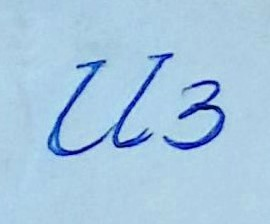

In [13]:
img_path = final_df[final_df['label'].notna()].iloc[0]['image_path']
print(img_path)
image = Image.open(img_path + '.jpg').convert('RGB')
display(image)

# Подготавливаем данные

In [14]:
train_df, temp_df = train_test_split(final_df, test_size=0.2, random_state=42, stratify=None)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=None)

In [15]:
train_images = train_df['image_path'].tolist()
train_texts = train_df['label'].astype(str).tolist()

val_images = val_df['image_path'].tolist()
val_texts = val_df['label'].astype(str).tolist()

test_images = test_df['image_path'].tolist()
test_texts = test_df['label'].astype(str).tolist()

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [17]:
processor = TrOCRProcessor.from_pretrained('kazars24/trocr-base-handwritten-ru')
model = VisionEncoderDecoderModel.from_pretrained('kazars24/trocr-base-handwritten-ru')

model.to(device)

model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

In [18]:
class CustomerDataset(Dataset):
    def __init__(self, image_paths, texts, processor, augment=False):
        self.image_paths = image_paths
        self.texts = texts
        self.processor = processor
        
        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomRotation(degrees=2), 
                transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
                # transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
            ])
        else:
            self.augmentation = None

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx] + '.jpg'
        text = str(self.texts[idx])
        
        try:
            img = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            if img_path.endswith('.jpg'):
                img_path = img_path.replace('.jpg', '.png')
            elif img_path.endswith('.png'):
                img_path = img_path.replace('.png', '.jpg')
            else:
                print(f'Формат изображения неизвестен - {self.image_path}')
            img = Image.open(img_path).convert('RGB')
        
        if self.augmentation:
            img = self.augmentation(img)
        
        pixel_values = self.processor(images=img, return_tensors='pt').pixel_values[0]
        labels = self.processor(text=text, return_tensors='pt').input_ids[0]
        
        return {'pixel_values': pixel_values, 'labels': labels}

In [19]:
def customer_collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = [item['labels'] for item in batch]
    
    labels_padded = rnn_utils.pad_sequence(
        labels,
        batch_first=True,
        padding_value=processor.tokenizer.pad_token_id
    )
    
    return {'pixel_values': pixel_values, 'labels': labels_padded}

In [20]:
train_dataset_customer = CustomerDataset(train_images, train_texts, processor, augment=True)
val_dataset_customer = CustomerDataset(val_images, val_texts, processor, augment=False)
test_dataset_customer = CustomerDataset(test_images, test_texts, processor, augment=False)

In [21]:
batch_size = 8 

train_loader = DataLoader(
    train_dataset_customer, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset_customer, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset_customer, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

model.config.decoder.dropout = 0.05
model.config.encoder.hidden_dropout_prob = 0.05


In [22]:
os.makedirs("./training_logs", exist_ok=True)

In [23]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("./training_logs/training.log", encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

## Обучаем (на данных заказчика)

In [24]:
LR = 2e-6
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
EPOCHS = 4
accumulation_steps = 2 

num_training_steps = len(train_loader) * EPOCHS // accumulation_steps
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [25]:
logger.info("="*60)
logger.info("НАЧАЛО ОБУЧЕНИЯ НА ДАННЫХ ЗАКАЗЧИКА")
logger.info("="*60)
logger.info(f"Размер обучающей выборки: {len(train_dataset_customer)}")
logger.info(f"Размер валидационной выборки: {len(val_dataset_customer)}")
logger.info(f"Batch size: {batch_size}")
logger.info(f"Epochs: {EPOCHS}")
logger.info(f"Learning rate: {LR}")
logger.info(f"Device: {device}")

2026-05-20 19:14:09,890 - INFO - ============================================================
2026-05-20 19:14:09,891 - INFO - НАЧАЛО ОБУЧЕНИЯ НА ДАННЫХ ЗАКАЗЧИКА
2026-05-20 19:14:09,891 - INFO - ============================================================
2026-05-20 19:14:09,892 - INFO - Размер обучающей выборки: 2409
2026-05-20 19:14:09,893 - INFO - Размер валидационной выборки: 301
2026-05-20 19:14:09,894 - INFO - Batch size: 8
2026-05-20 19:14:09,894 - INFO - Epochs: 4
2026-05-20 19:14:09,895 - INFO - Learning rate: 2e-06
2026-05-20 19:14:09,895 - INFO - Device: cuda


In [26]:
metrics_log = []
csv_filename = "./training_logs/metrics.csv"

In [27]:
best_val_cer = float('inf')
best_val_wer = float('inf')
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    epoch_start_time = datetime.now()
    # Train
    model.train()
    train_loss_total = 0
    optimizer.zero_grad()
    
    with tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]") as pbar:
        for i, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / accumulation_steps
            loss.backward()
            
            train_loss_total += outputs.loss.item() / accumulation_steps
            
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            pbar.set_postfix({'loss': f'{outputs.loss.item():.4f}'})
            
            del pixel_values, labels, outputs, loss
    
    avg_train_loss = train_loss_total / len(train_loader)
    
    # Validation
    model.eval()
    val_loss_total = 0
    val_cer_scores = []
    val_wer_scores = []
    
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]") as pbar:
            for batch in pbar:
                pixel_values = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss_total += outputs.loss.item()
                
                generated_ids = model.generate(
                    pixel_values, 
                    max_length=64,
                    num_beams=2,
                    early_stopping=True
                )
                
                pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
                true_texts = processor.batch_decode(labels, skip_special_tokens=True)
                
                for pred, true in zip(pred_texts, true_texts):
                    val_cer_scores.append(cer(true, pred))
                    val_wer_scores.append(wer(true, pred))
                
                pbar.set_postfix({
                    'val_loss': f'{outputs.loss.item():.4f}',
                    'val_CER': f'{sum(val_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                    'val_WER': f'{sum(val_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
                })
                
                del pixel_values, labels, outputs, generated_ids

    epoch_end_time = datetime.now()
    epoch_duration = (epoch_end_time - epoch_start_time).total_seconds()
    
    avg_val_loss = val_loss_total / len(val_loader)
    avg_val_cer = sum(val_cer_scores) / len(val_cer_scores)
    avg_val_wer = sum(val_wer_scores) / len(val_wer_scores)

    logger.info(f"Epoch {epoch+1}/{EPOCHS} завершена за {epoch_duration:.1f} сек")
    logger.info(f"  Train Loss: {avg_train_loss:.4f}")
    logger.info(f"  Val Loss: {avg_val_loss:.4f}")
    logger.info(f"  Val CER: {avg_val_cer:.4f}")
    logger.info(f"  Val WER: {avg_val_wer:.4f}")
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val CER={avg_val_cer:.4f}, Val WER={avg_val_wer:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_cer = avg_val_cer
        best_val_wer = avg_val_wer
        model.save_pretrained("./best_model_customer")
        processor.save_pretrained("./best_model_customer")
        print(f" Сохранена лучшая модель (CER={avg_val_cer:.4f}), WER={avg_val_wer:.4f})")

print(f"Обучение завершено. Лучшие CER: {best_val_cer:.4f}, WER: {best_val_wer:.4f}")

Epoch 1 [Val]: 100%|██████████| 38/38 [00:39<00:00,  1.04s/it, val_loss=0.2964, val_CER=0.4860, val_WER=1.2000]
2026-05-20 19:17:09,148 - INFO - Epoch 1/4 завершена за 179.2 сек
2026-05-20 19:17:09,148 - INFO -   Train Loss: 1.5911
2026-05-20 19:17:09,149 - INFO -   Val Loss: 0.3807
2026-05-20 19:17:09,150 - INFO -   Val CER: 0.2965
2026-05-20 19:17:09,150 - INFO -   Val WER: 0.6041


Epoch 1/4: Train Loss=1.5911, Val Loss=0.3807, Val CER=0.2965, Val WER=0.6041


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Сохранена лучшая модель (CER=0.2965), WER=0.6041)


Epoch 2 [Val]: 100%|██████████| 38/38 [00:39<00:00,  1.04s/it, val_loss=0.2485, val_CER=0.4575, val_WER=1.2000]
2026-05-20 19:20:10,760 - INFO - Epoch 2/4 завершена за 180.5 сек
2026-05-20 19:20:10,760 - INFO -   Train Loss: 0.2018
2026-05-20 19:20:10,761 - INFO -   Val Loss: 0.3329
2026-05-20 19:20:10,761 - INFO -   Val CER: 0.2626
2026-05-20 19:20:10,762 - INFO -   Val WER: 0.5753


...

 Сохранена лучшая модель (CER=0.2515), WER=0.5559)


Epoch 4 [Val]: 100%|██████████| 38/38 [00:40<00:00,  1.06s/it, val_loss=0.2175, val_CER=0.4575, val_WER=1.0000]
2026-05-20 19:26:15,273 - INFO - Epoch 4/4 завершена за 182.3 сек
2026-05-20 19:26:15,274 - INFO -   Train Loss: 0.1626
2026-05-20 19:26:15,274 - INFO -   Val Loss: 0.3143
2026-05-20 19:26:15,275 - INFO -   Val CER: 0.2506
2026-05-20 19:26:15,275 - INFO -   Val WER: 0.5460


Epoch 4/4: Train Loss=0.1626, Val Loss=0.3143, Val CER=0.2506, Val WER=0.5460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Сохранена лучшая модель (CER=0.2506), WER=0.5460)
Обучение завершено. Лучшие CER: 0.2506, WER: 0.5460


# Модель на данных заказчика

In [28]:
model = VisionEncoderDecoderModel.from_pretrained("./best_model_customer")
processor = TrOCRProcessor.from_pretrained("./best_model_customer")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.05, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.05, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            

In [29]:
test_cer_scores = []
test_wer_scores = []

test_loss_total = 0

with torch.no_grad():
    with tqdm(test_loader, desc="Testing") as pbar:
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            generated_ids = model.generate(pixel_values, max_length=64, num_beams=2)
            outputs = model(pixel_values=pixel_values, labels=labels)
            test_loss_total += outputs.loss.item()
            
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            true_texts = processor.batch_decode(labels, skip_special_tokens=True)
            
            for pred, true in zip(pred_texts, true_texts):
                test_cer_scores.append(cer(true, pred))
                test_wer_scores.append(wer(true, pred))
            
            pbar.set_postfix({
                'test_loss': f'{outputs.loss.item():.4f}',
                'test_CER': f'{sum(test_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                'test_WER': f'{sum(test_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
            })
           
            del pixel_values, labels, generated_ids, outputs

avg_test_loss = test_loss_total / len(test_loader)
avg_test_cer = sum(test_cer_scores) / len(test_cer_scores)
avg_test_wer = sum(test_wer_scores) / len(test_wer_scores)

print(f"\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Average CER: {avg_test_cer:.4f}")
print(f"Average WER: {avg_test_wer:.4f}")

Testing: 100%|██████████| 38/38 [00:42<00:00,  1.13s/it, test_loss=0.1697, test_CER=0.1250, test_WER=0.4167]


=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===
Test Loss: 0.3284
Average CER: 0.2284
Average WER: 0.5552


In [30]:
final_df.to_csv('customer_dataset_labels_3012.csv', index=False, encoding='utf-8-sig')

# Дообучение на кагл данных

In [31]:
logger.info("="*60)
logger.info("ЗАГРУЗКА KAGGLE ДАТАСЕТА")
logger.info("="*60)

2026-05-20 19:27:00,745 - INFO - ============================================================
2026-05-20 19:27:00,746 - INFO - ЗАГРУЗКА KAGGLE ДАТАСЕТА
2026-05-20 19:27:00,747 - INFO - ============================================================


In [32]:
kaggle_path = kagglehub.dataset_download("constantinwerner/cyrillic-handwriting-dataset")

In [33]:
df_train = pd.read_csv(os.path.join(kaggle_path, "train.tsv"), sep='\t', header=None, names=['image', 'text'])
df_test = pd.read_csv(os.path.join(kaggle_path, "test.tsv"), sep='\t', header=None, names=['image', 'text'])
# df_kaggle = pd.concat([df_train, df_test], ignore_index=True)
df_kaggle = df_train


In [34]:
print(f"Train samples: {len(df_train)}")
print(f"Test samples: {len(df_test)}")
print(f"Total samples: {len(df_kaggle)}")
print(df_kaggle.head())

Train samples: 72286
Test samples: 1544
Total samples: 72286
        image               text
0     aa1.png            Молдова
1  aa1007.png  продолжила борьбу
2   aa101.png      разработанные
3  aa1012.png              Плачи
4  aa1013.png        Гимны богам


In [35]:
image_col = 'image'
text_col = 'text'

def find_img(fname):
    for folder in ['train', 'test']:
        path = os.path.join(kaggle_path, folder, fname)
        if os.path.exists(path):
            return path
    return None

df_kaggle['image_path'] = df_kaggle[image_col].apply(find_img)
df_kaggle['label'] = df_kaggle[text_col].astype(str)
df_kaggle = df_kaggle.dropna(subset=['image_path'])

df_kaggle_sample = df_kaggle.sample(n=10000, random_state=42)
print(f"Kaggle датасет: {len(df_kaggle_sample)} образцов")


Kaggle датасет: 10000 образцов


In [36]:
final_df = pd.concat([final_df, df_kaggle[['image_path', 'label']]], ignore_index=True)
print(f"Общий датасет: {len(final_df)} образцов")
print(final_df)

Общий датасет: 75298 образцов
                                              image_path  \
0                 C:/Users/maill/WORK/Dataset/32_1/img_1   
1                 C:/Users/maill/WORK/Dataset/32_1/img_2   
2                 C:/Users/maill/WORK/Dataset/32_1/img_3   
3                 C:/Users/maill/WORK/Dataset/32_1/img_4   
4                 C:/Users/maill/WORK/Dataset/32_1/img_5   
...                                                  ...   
75293  C:\Users\maill\.cache\kagglehub\datasets\const...   
75294  C:\Users\maill\.cache\kagglehub\datasets\const...   
75295  C:\Users\maill\.cache\kagglehub\datasets\const...   
75296  C:\Users\maill\.cache\kagglehub\datasets\const...   
75297  C:\Users\maill\.cache\kagglehub\datasets\const...   

                       label  
0                         Из  
1                     архива  
2                         П.  
3                         П.  
4                     Бажова  
...                      ...  
75293  Ответственность в/сл-  
7

In [37]:
model = VisionEncoderDecoderModel.from_pretrained("./best_model_customer")
model.to(device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.05, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.05, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            

In [38]:
train_df_combined, temp_df_combined = train_test_split(final_df, test_size=0.2, random_state=42)
val_df_combined, test_df_combined = train_test_split(temp_df_combined, test_size=0.5, random_state=42)

In [39]:
class CustomerDataset(Dataset):
    def __init__(self, image_paths, texts, processor, augment=False):
        self.image_paths = image_paths
        self.texts = texts
        self.processor = processor
        
        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomRotation(degrees=2), 
                transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
                # transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0)),
            ])
        else:
            self.augmentation = None

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        text = str(self.texts[idx])
        
        if not img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            for ext in ['.jpg', '.png']:
                test_path = img_path + ext
                if os.path.exists(test_path):
                    img_path = test_path
                    break
        
        img = Image.open(img_path).convert('RGB')

        
        if self.augmentation:
            img = self.augmentation(img)
        
        pixel_values = self.processor(images=img, return_tensors='pt').pixel_values[0]
        labels = self.processor(text=text, return_tensors='pt').input_ids[0]
        
        return {'pixel_values': pixel_values, 'labels': labels}

In [40]:
train_dataset_combined = CustomerDataset(
    train_df_combined['image_path'].tolist(), 
    train_df_combined['label'].astype(str).tolist(), 
    processor, 
    augment=True
)
val_dataset_combined = CustomerDataset(
    val_df_combined['image_path'].tolist(), 
    val_df_combined['label'].astype(str).tolist(), 
    processor, 
    augment=False
)

In [41]:
batch_size = 16
train_loader_combined = DataLoader(
    train_dataset_combined, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=customer_collate_fn,
    num_workers=4
)
val_loader_combined = DataLoader(
    val_dataset_combined, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=customer_collate_fn,
    num_workers=0
)

In [42]:
LR = 0.001

optimizer_finetune = torch.optim.AdamW(model.parameters(), lr=LR)
EPOCHS_FINETUNE = 1

num_training_steps = len(train_loader_combined) * EPOCHS_FINETUNE
num_warmup_steps = int(0.1 * num_training_steps)

scheduler_finetune = get_linear_schedule_with_warmup(
    optimizer_finetune,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [43]:
finetune_logger = logging.getLogger('finetune')
finetune_logger.setLevel(logging.INFO)

In [44]:
if finetune_logger.handlers:
        finetune_logger.handlers.clear()

In [45]:
fh = logging.FileHandler("./training_logs/finetune.log", encoding='utf-8')
fh.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
finetune_logger.addHandler(fh)
finetune_logger.addHandler(logging.StreamHandler())

In [46]:
finetune_logger.info("="*60)
finetune_logger.info("НАЧАЛО ДООБУЧЕНИЯ НА KAGGLE ДАТАСЕТЕ")
finetune_logger.info("="*60)
finetune_logger.info(f"Размер обучающей выборки: {len(train_dataset_combined)}")
finetune_logger.info(f"Размер валидационной выборки: {len(val_dataset_combined)}")
finetune_logger.info(f"Epochs: {EPOCHS_FINETUNE}")
finetune_logger.info(f"Learning rate: {LR}")

2026-05-20 19:27:07,617 - INFO - ============================================================
НАЧАЛО ДООБУЧЕНИЯ НА KAGGLE ДАТАСЕТЕ
2026-05-20 19:27:07,618 - INFO - НАЧАЛО ДООБУЧЕНИЯ НА KAGGLE ДАТАСЕТЕ
2026-05-20 19:27:07,620 - INFO - ============================================================
Размер обучающей выборки: 60238
2026-05-20 19:27:07,621 - INFO - Размер обучающей выборки: 60238
Размер валидационной выборки: 7530
2026-05-20 19:27:07,622 - INFO - Размер валидационной выборки: 7530
Epochs: 1
2026-05-20 19:27:07,624 - INFO - Epochs: 1
Learning rate: 0.001
2026-05-20 19:27:07,625 - INFO - Learning rate: 0.001


In [ ]:
best_val_cer = float('inf')
best_val_wer = float('inf')
best_val_loss = float('inf')

finetune_metrics = []
finetune_csv = "./training_logs/metrics_finetune.csv"

for epoch in range(EPOCHS_FINETUNE):
    epoch_start = datetime.now()
    
    # Train
    model.train()
    train_loss_total = 0
    optimizer_finetune.zero_grad()
    
    with tqdm(train_loader_combined, desc=f"Finetune Epoch {epoch+1} [Train]") as pbar:
        for i, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            loss.backward()
            
            train_loss_total += loss.item()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_finetune.step()
            scheduler_finetune.step()
            optimizer_finetune.zero_grad()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            
            del pixel_values, labels, outputs, loss
    
    avg_train_loss = train_loss_total / len(train_loader_combined)
    
    # Validation
    model.eval()
    val_loss_total = 0
    val_cer_scores = []
    val_wer_scores = []
    
    with torch.no_grad():
        with tqdm(val_loader_combined, desc=f"Finetune Epoch {epoch+1} [Val]") as pbar:
            for batch in pbar:
                pixel_values = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss_total += outputs.loss.item()
                
                generated_ids = model.generate(pixel_values, max_length=64, num_beams=2)
                pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
                true_texts = processor.batch_decode(labels, skip_special_tokens=True)
                
                for pred, true in zip(pred_texts, true_texts):
                    val_cer_scores.append(cer(true, pred))
                    val_wer_scores.append(wer(true, pred))
                
                pbar.set_postfix({
                    'val_CER': f'{val_cer_scores[-1]:.4f}' if val_cer_scores else '0',
                })
                
                del pixel_values, labels, outputs, generated_ids
    
    epoch_duration = (datetime.now() - epoch_start).total_seconds()
    avg_val_loss = val_loss_total / len(val_loader_combined)
    avg_val_cer = sum(val_cer_scores) / len(val_cer_scores)
    avg_val_wer = sum(val_wer_scores) / len(val_wer_scores)
    
    finetune_logger.info(f"Epoch {epoch+1}/{EPOCHS_FINETUNE} за {epoch_duration:.1f} сек")
    finetune_logger.info(f"  Train Loss: {avg_train_loss:.4f}")
    finetune_logger.info(f"  Val Loss: {avg_val_loss:.4f}")
    finetune_logger.info(f"  Val CER: {avg_val_cer:.4f}")
    finetune_logger.info(f"  Val WER: {avg_val_wer:.4f}")
    
    finetune_metrics.append({
        'epoch': epoch+1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_cer': avg_val_cer,
        'val_wer': avg_val_wer,
        'duration_sec': epoch_duration
    })
    
    with open(finetune_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=finetune_metrics[0].keys())
        writer.writeheader()
        writer.writerows(finetune_metrics)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_cer = avg_val_cer
        best_val_wer = avg_val_wer
        model.save_pretrained("./best_model_finetuned")
        processor.save_pretrained("./best_model_finetuned")
        finetune_logger.info(f"Сохранена лучшая дообученная модель (CER={avg_val_cer:.4f})")

finetune_logger.info("="*60)
finetune_logger.info(f"ДООБУЧЕНИЕ ЗАВЕРШЕНО")
finetune_logger.info(f"Лучший CER: {best_val_cer:.4f}")
finetune_logger.info(f"Лучший WER: {best_val_wer:.4f}")
finetune_logger.info("="*60)

print(f"\n Дообучение завершено!")
print(f"Логи: ./training_logs/finetune.log")
print(f"Метрики: ./training_logs/metrics_finetune.csv")
print(f"Модель: ./best_model_finetuned")

Finetune Epoch 1 [Train]:   0%|          | 0/3765 [00:00<?, ?it/s]

In [ ]:
test_cer_scores = []
test_wer_scores = []

test_loss_total = 0

with torch.no_grad():
    with tqdm(test_loader, desc="Testing") as pbar:
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            generated_ids = model.generate(pixel_values, max_length=64, num_beams=2)
            outputs = model(pixel_values=pixel_values, labels=labels)
            test_loss_total += outputs.loss.item()
            
            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
            true_texts = processor.batch_decode(labels, skip_special_tokens=True)
            
            for pred, true in zip(pred_texts, true_texts):
                test_cer_scores.append(cer(true, pred))
                test_wer_scores.append(wer(true, pred))
            
            pbar.set_postfix({
                'test_loss': f'{outputs.loss.item():.4f}',
                'test_CER': f'{sum(test_cer_scores[-len(pred_texts):])/len(pred_texts):.4f}',
                'test_WER': f'{sum(test_wer_scores[-len(pred_texts):])/len(pred_texts):.4f}'
            })
           
            del pixel_values, labels, generated_ids, outputs

avg_test_loss = test_loss_total / len(test_loader)
avg_test_cer = sum(test_cer_scores) / len(test_cer_scores)
avg_test_wer = sum(test_wer_scores) / len(test_wer_scores)

print(f"\n=== РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ ===")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Average CER: {avg_test_cer:.4f}")
print(f"Average WER: {avg_test_wer:.4f}")